# 01 - Data cleaning and feature engineering

Purpose: audit the raw IBM Telco file, remove unsafe identifiers, encode categories, create business features, and save a numeric modeling table.

Report: explain missing TotalCharges, dropping customerID, binary encoding, tenure bands, service counts, and charge interactions.

Raw shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


customerID         0
gender             0
SeniorCitizen      0
Partner            0
Dependents         0
tenure             0
PhoneService       0
MultipleLines      0
InternetService    0
OnlineSecurity     0
dtype: int64

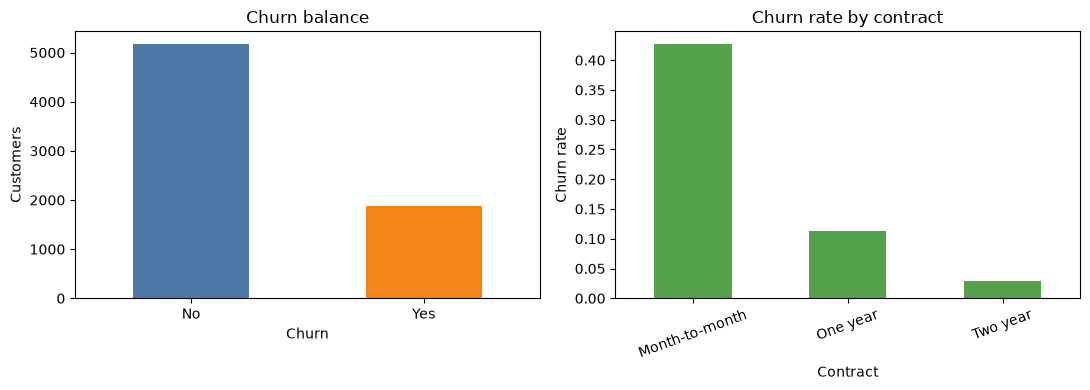

In [4]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make paths work from either the project root or the notebooks folder.
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
raw = pd.read_csv(ROOT / 'data' / 'telco.csv')
print('Raw shape:', raw.shape)
display(raw.head())
display(raw.isna().sum().sort_values(ascending=False).head(10))

# Visual audit: churn balance and churn rate by contract.
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
raw['Churn'].value_counts().reindex(['No', 'Yes']).plot(kind='bar', ax=axes[0], color=['#4C78A8', '#F58518'])
axes[0].set_title('Churn balance'); axes[0].set_ylabel('Customers'); axes[0].tick_params(axis='x', rotation=0)
contract_rate = raw.groupby('Contract')['Churn'].apply(lambda values: (values == 'Yes').mean())
contract_rate.plot(kind='bar', ax=axes[1], color='#54A24B')
axes[1].set_title('Churn rate by contract'); axes[1].set_ylabel('Churn rate'); axes[1].tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()

## Cleaning rules

Blank TotalCharges values are converted to zero because they correspond to customers with zero tenure. customerID is removed because it is only an identifier. Text yes/no fields are converted to 1/0 so models can use them.

In [5]:
df = raw.copy()

# Convert charges before creating numerical features.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].astype(str).str.strip(), errors='coerce').fillna(0.0)
df = df.drop(columns=['customerID'])
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0}).astype(int)

binary_columns = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for column in binary_columns:
    df[column] = df[column].map({'Yes': 1, 'No': 0}).astype(int)

addon_columns = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'MultipleLines']
for column in addon_columns:
    df[column] = df[column].replace({'No internet service': 'No', 'No phone service': 'No'}).map({'Yes': 1, 'No': 0}).astype(int)

## Feature engineering

These features express reasonable business hypotheses: contract length, customer age, service breadth, price pressure, and revenue history. They remain associations until validated.

In [6]:
# Encode ordered contract length.
df['Contract'] = df['Contract'].map({'Month-to-month': 0, 'One year': 1, 'Two year': 2}).astype(int)

# Create readable binary indicators for categorical variables.
df['gender_Male'] = (df['gender'] == 'Male').astype(int)
df = df.drop(columns=['gender'])
df['InternetService_Fiber'] = (df['InternetService'] == 'Fiber optic').astype(int)
df['InternetService_None'] = (df['InternetService'] == 'No').astype(int)
df = df.drop(columns=['InternetService'])
payment_dummies = pd.get_dummies(df['PaymentMethod'], prefix='PaymentMethod', drop_first=True).astype(int)
df = pd.concat([df.drop(columns=['PaymentMethod']), payment_dummies], axis=1)

# Automatic bank transfer or credit card payment is a retention-related convenience signal.
df['AutoPay'] = (
    (df['PaymentMethod_Credit card (automatic)'] == 1)
    | (
        (df['PaymentMethod_Electronic check'] == 0)
        & (df['PaymentMethod_Mailed check'] == 0)
    )
).astype(int)

service_columns = ['PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
df['NumServices'] = df[service_columns].sum(axis=1)
df['TenureBin'] = pd.cut(df['tenure'], bins=[-1, 6, 12, 24, 36, 1000], labels=[0, 1, 2, 3, 4]).astype(int)
df['HighChargeFlag'] = (df['MonthlyCharges'] > df['MonthlyCharges'].quantile(.75)).astype(int)
df['Contract_x_Charge'] = df['Contract'] * df['MonthlyCharges']
df['Fiber_x_Charge'] = df['InternetService_Fiber'] * df['MonthlyCharges']
df['ChargesPerTenure'] = df['TotalCharges'] / (df['tenure'] + 1)
df['LogMonthlyCharges'] = np.log1p(df['MonthlyCharges'])
df['LogTotalCharges'] = np.log1p(df['TotalCharges'])
df['IsNewCustomer'] = (df['tenure'] <= 6).astype(int)

# Final safety checks prevent a dirty table entering model training.
assert df.isna().sum().sum() == 0
assert df.select_dtypes(exclude='number').empty
feature_count = df.shape[1] - 1  # Exclude the Churn target.
assert feature_count == 32, f'Expected 32 predictor columns, found {feature_count}'
OUTPUT_PATH = ROOT / 'data' / 'telco_clean_32col.csv'
df.to_csv(OUTPUT_PATH, index=False)
print('Saved:', OUTPUT_PATH, 'Shape:', df.shape, 'Churn rate:', round(df['Churn'].mean(), 3))

Saved: c:\Users\mikil\Saved Games\new\data\telco_clean_32col.csv Shape: (7043, 33) Churn rate: 0.265


## Interpretation

The cleaning notebook is successful when the output has no missing values, a binary target, numeric features, and a documented final shape. Do not claim that an engineered feature causes churn.